
# Projekt

**Cel:** przeprowadzić kompletny projekt ML w oparciu o **tradycyjne algorytmy** i narzędzia scikit-learn
Wszystkie kroki są rozdzielone na **zadania** w osobnych komórkach.

**Dane:** `"projekt_dane.csv"`



## Zasady i wymagania
- Używamy wyłącznie **tradycyjnego ML**: k-NN, regresja logistyczna, regresja liniowa, k-means.
- **Żadnych ręcznych encodingów** (poza *parsowaniem listy*); użyj `Pipeline`, `ColumnTransformer`, `SimpleImputer`, `OneHotEncoder`, `StandardScaler`.
- Kolumny listowe (np. `Recycling`, `Cooking_With`) przetwarzamy **funkcją/transformatorem** i włączamy w `ColumnTransformer`.


## Zadanie 0 — Importy i konfiguracja

In [14]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score, silhouette_score
)
from sklearn.base import BaseEstimator, TransformerMixin

DATA_PATH = "projekt_dane.csv"


print("Wersje:")
import sklearn; print("sklearn", sklearn.__version__)
print("pandas", pd.__version__)
print("numpy", np.__version__)


Wersje:
sklearn 1.8.0
pandas 3.0.2
numpy 2.4.4


## Zadanie 1 — Wczytanie danych

In [ ]:


df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(10))
df.info()


Shape: (10000, 20)


,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743
5,overweight,male,vegetarian,less frequently,wood,public,NaN,sometimes,144,frequently,658,large,1,22,18,9,Sometimes,"['Paper', 'Glass', 'Metal']","['Stove', 'Oven', 'Microwave']",1647
6,underweight,female,vegan,less frequently,wood,private,hybrid,never,56,rarely,5363,medium,4,9,11,19,Sometimes,[],"['Grill', 'Airfryer']",1832
7,underweight,female,vegan,more frequently,coal,walk/bicycle,NaN,sometimes,59,very frequently,54,extra large,3,5,39,15,No,"['Paper', 'Plastic', 'Glass']","['Stove', 'Microwave']",2322
8,overweight,male,omnivore,daily,wood,public,NaN,never,200,frequently,1376,medium,3,3,31,15,Yes,['Glass'],"['Microwave', 'Grill', 'Airfryer']",2494
9,underweight,female,pescatarian,daily,wood,public,NaN,often,135,rarely,440,extra large,1,8,23,18,Sometimes,['Glass'],"['Microwave', 'Grill', 'Airfryer']",1178


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Body Type                      10000 non-null  str  
 1   Sex                            10000 non-null  str  
 2   Diet                           10000 non-null  str  
 3   How Often Shower               10000 non-null  str  
 4   Heating Energy Source          10000 non-null  str  
 5   Transport                      10000 non-null  str  
 6   Vehicle Type                   3279 non-null   str  
 7   Social Activity                10000 non-null  str  
 8   Monthly Grocery Bill           10000 non-null  int64
 9   Frequency of Traveling by Air  10000 non-null  str  
 10  Vehicle Monthly Distance Km    10000 non-null  int64
 11  Waste Bag Size                 10000 non-null  str  
 12  Waste Bag Weekly Count         10000 non-null  int64
 13  How Long TV PC Daily Hour   

## Zadanie 2 — Słownik danych (do uzupełnienia)


- Body Type — kategoryczna
- Sex — kategoryczna
- Diet — kategoryczna
- How Often Shower — kategoryczna
- Heating Energy Source — kategoryczna
- Transport — kategoryczna
- Vehicle Type — kategoryczna
- Social Activity — kategoryczna
- Monthly Grocery Bill — numeryczna
- Frequency of Traveling by Air — kategoryczna
- Vehicle Monthly Distance Km — numeryczna
- Waste Bag Size — kategoryczna
- Waste Bag Weekly Count — numeryczna
- How Long TV PC Daily Hour — numeryczna
- How Many New Clothes Monthly — numeryczna
- How Long Internet Daily Hour — numeryczna
- Energy efficiency — kategoryczna
- Recycling (lista) — listowa
- Cooking_With (lista) — listowa
- CarbonEmission — numeryczna  


## Zadanie 3 — EDA: braki danych i statystyki

In [ ]:

#sprawdź braki danych oraz statystyki opisowe.


In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

print("Braki danych (liczba):")
display(missing[missing > 0])

print("\nBraki danych (%):")
display(missing_pct[missing_pct > 0])

print("\nStatystyki opisowe (wszystkie kolumny):")
display(df.describe(include='all'))

Braki danych (liczba):


Vehicle Type    6721
dtype: int64


Braki danych (%):


Vehicle Type    67.21
dtype: float64


Statystyki opisowe (wszystkie kolumny):


,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
count,10000,10000,10000,10000,10000,10000,3279,10000,10000.000000,10000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000,10000.000000
unique,4,2,4,4,4,3,5,3,NaN,4,NaN,4,NaN,NaN,NaN,NaN,3,16,16,NaN
top,underweight,female,pescatarian,daily,electricity,walk/bicycle,lpg,never,NaN,very frequently,NaN,small,NaN,NaN,NaN,NaN,Sometimes,[],"['Stove', 'Oven']",NaN
freq,2540,5007,2554,2546,2552,3427,697,3406,NaN,2540,NaN,2525,NaN,NaN,NaN,NaN,3463,675,670,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.875200,NaN,2031.485900,NaN,4.024600,12.139200,25.109000,11.889100,NaN,NaN,NaN,2269.147300
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72.234018,NaN,2769.715597,NaN,1.990375,7.106369,14.698725,7.277218,NaN,NaN,NaN,1017.675247
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.000000,NaN,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,306.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.000000,NaN,69.000000,NaN,2.000000,6.000000,13.000000,6.000000,NaN,NaN,NaN,1538.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,NaN,823.000000,NaN,4.000000,12.000000,25.000000,12.000000,NaN,NaN,NaN,2080.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,237.000000,NaN,2516.750000,NaN,6.000000,18.000000,38.000000,18.000000,NaN,NaN,NaN,2768.000000


## Zadanie 4 — EDA: wizualizacje

In [ ]:

#WIZUALIZACJE (opcjonalnie) - np.histogram, boxplot, scatter_matrix, heatmap korelacji itp.


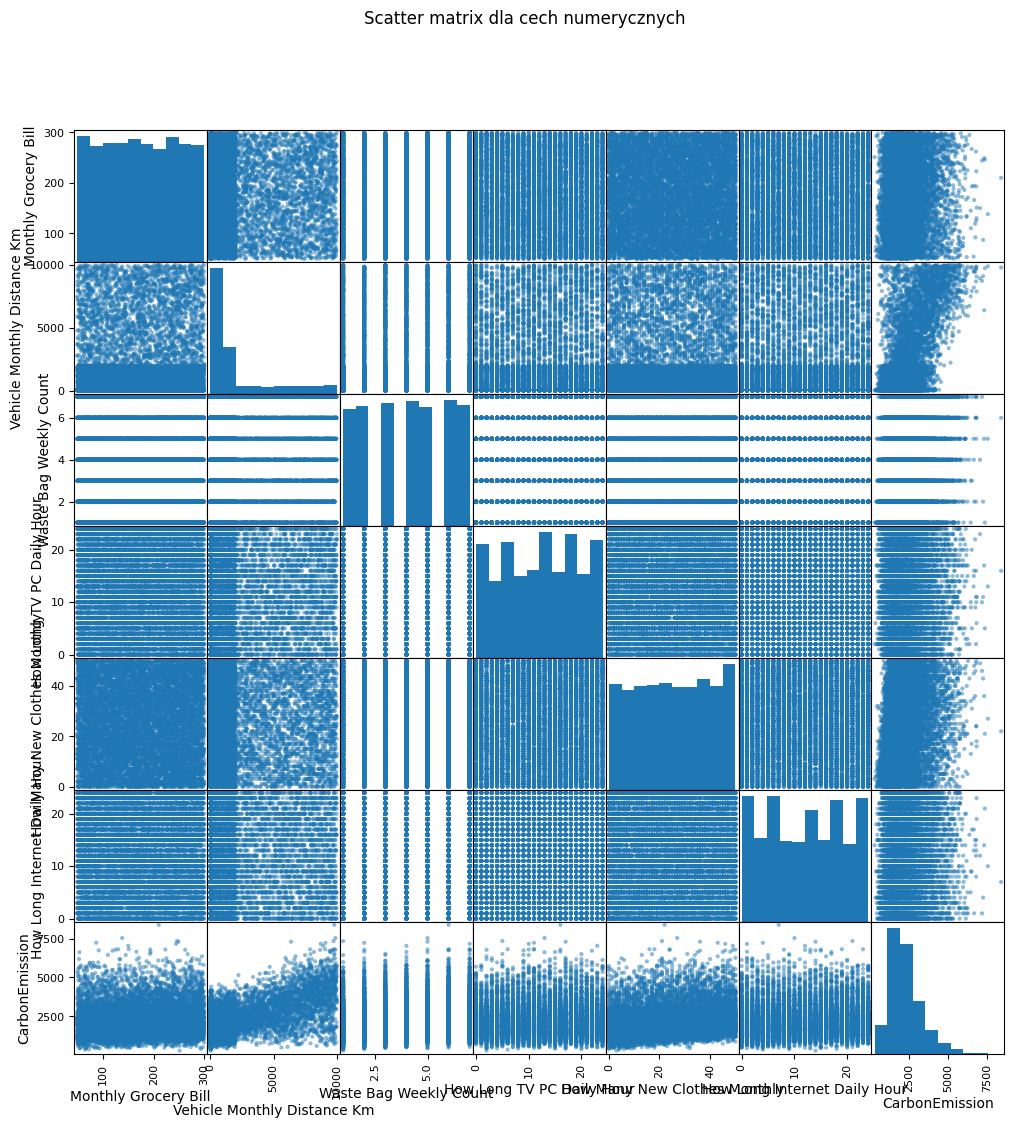

In [4]:
numeric_df = df.select_dtypes(include=[np.number])
pd.plotting.scatter_matrix(numeric_df, figsize=(12, 12), diagonal='hist', alpha=0.5)
plt.suptitle("Scatter matrix dla cech numerycznych")
plt.show()

## Zadanie 5 — Transformator dla kolumn listowych (MultiLabelBinarizer)


Zaimplementuj transformator scikit-learn, który:
1) parsuje stringową listę (np. `"['Paper','Plastic']"`) do listy Pythona,  
2) koduje wieloetykietowo przy pomocy `MultiLabelBinarizer`,  
3) współpracuje z `ColumnTransformer` i udostępnia `get_feature_names_out()`.


Ta częśc jest już stworzona i wypełniona, nie musisz nic zmieniac

In [5]:

class ListToMLB(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb_ = MultiLabelBinarizer()

    @staticmethod
    def _parse_cell(x):
        if isinstance(x, list):
            return x
        if isinstance(x, float) and pd.isna(x):
            return []
        if isinstance(x, str):
            s = x.strip()
            if s.startswith('[') and s.endswith(']'):
                try:
                    return ast.literal_eval(s)
                except Exception:
                    return []
            return []
        return []

    def fit(self, X, y=None):
        col = pd.Series(X.ravel()).apply(self._parse_cell)
        self.mlb_.fit(col)
        return self

    def transform(self, X):
        col = pd.Series(X.ravel()).apply(self._parse_cell)
        return self.mlb_.transform(col)

    def get_feature_names_out(self, input_features=None):
        return np.array([f"list__{c}" for c in self.mlb_.classes_], dtype=object)



**Jak zastosować ten transformator?**  
W `ColumnTransformer` dodaj osobny krok dla każdej kolumny listowej, np.:  
`('recycling', ListToMLB(), ['Recycling'])` oraz `('cooking', ListToMLB(), ['Cooking_With'])`.


## Zadanie 6 — Wybór kolumn do przetwarzania

In [6]:

# TODO: dostosuj listy kolumn do istniejących w danych.
num_cols = [
    'Monthly Grocery Bill',
    'Vehicle Monthly Distance Km',
    'Waste Bag Weekly Count',
    'How Long TV PC Daily Hour',
    'How Many New Clothes Monthly',
    'How Long Internet Daily Hour'
]

cat_cols = [
    'Body Type',
    'Sex',
    'Diet',
    'How Often Shower',
    'Heating Energy Source',
    'Transport',
    'Vehicle Type',
    'Social Activity',
    'Waste Bag Size',
    'Frequency of Traveling by Air',
    'Energy efficiency'
]

list_cols = [
    'Recycling',
    'Cooking_With'
]

print("Numeryczne:", num_cols)
print("Kategoryczne:", cat_cols)
print("Listowe:", list_cols)

print("Numeryczne:", num_cols)
print("Kategoryczne:", cat_cols)
print("Listowe:", list_cols)


Numeryczne: ['Monthly Grocery Bill', 'Vehicle Monthly Distance Km', 'Waste Bag Weekly Count', 'How Long TV PC Daily Hour', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour']
Kategoryczne: ['Body Type', 'Sex', 'Diet', 'How Often Shower', 'Heating Energy Source', 'Transport', 'Vehicle Type', 'Social Activity', 'Waste Bag Size', 'Frequency of Traveling by Air', 'Energy efficiency']
Listowe: ['Recycling', 'Cooking_With']
Numeryczne: ['Monthly Grocery Bill', 'Vehicle Monthly Distance Km', 'Waste Bag Weekly Count', 'How Long TV PC Daily Hour', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour']
Kategoryczne: ['Body Type', 'Sex', 'Diet', 'How Often Shower', 'Heating Energy Source', 'Transport', 'Vehicle Type', 'Social Activity', 'Waste Bag Size', 'Frequency of Traveling by Air', 'Energy efficiency']
Listowe: ['Recycling', 'Cooking_With']


## Zadanie 7 — Preprocessing z ColumnTransformer

In [8]:

num_pipe = None #TODO: uzupełnij pipeline dla cech numerycznych.

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

list_transforms = [
    (f'list_{i}', Pipeline([
        ('list', ListToMLB()),
    ]), [col]) for i, col in enumerate(list_cols)
]
preprocess = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
        *list_transforms
    ],
    remainder='drop'
)

preprocess


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

## Zadanie 8 — Definicja etykiety klasyfikacyjnej (HighEmission)

In [ ]:

q = 0.75  # TODO: możesz zmienić np. na 0.8
y_reg = df['CarbonEmission'].copy()
thr = y_reg.quantile(q)
y_clf = (y_reg >= thr).astype(int)

X = df.drop(columns=['CarbonEmission'])
print("Próg emisji:", thr, " | Udział klasy 1:", y_clf.mean().round(3))


Próg emisji: 2768.0  | Udział klasy 1: 0.25


## Zadanie 9 — Klasyfikacja: k-NN i Regresja Logistyczna (Pipeline + GridSearchCV)

=== k-NN (best) ===
ROC-AUC: 0.9237
              precision    recall  f1-score   support

           0     0.8731    0.9587    0.9139      1500
           1     0.8244    0.5820    0.6823       500

    accuracy                         0.8645      2000
   macro avg     0.8487    0.7703    0.7981      2000
weighted avg     0.8609    0.8645    0.8560      2000



<Figure size 640x480 with 0 Axes>

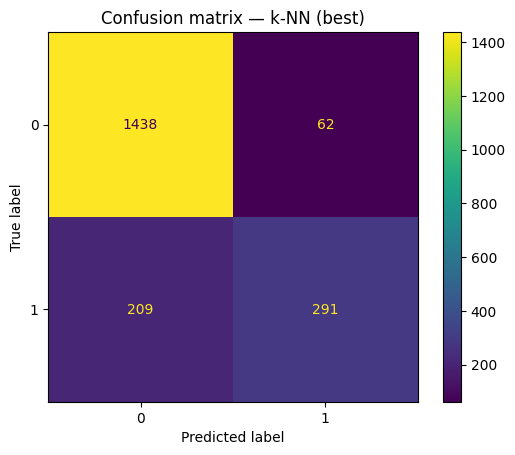

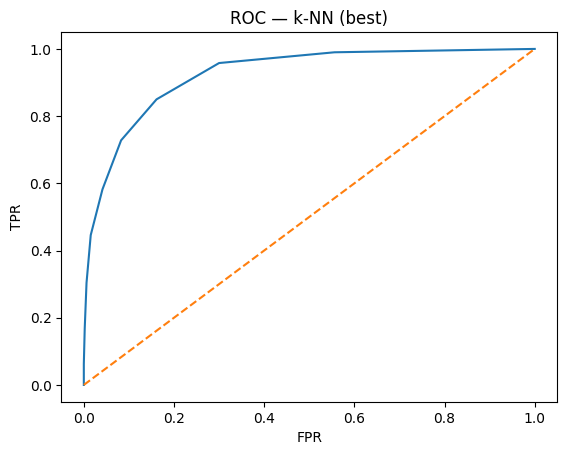

=== LogReg (best) ===
ROC-AUC: 0.9898
              precision    recall  f1-score   support

           0     0.9874    0.9440    0.9652      1500
           1     0.8516    0.9640    0.9043       500

    accuracy                         0.9490      2000
   macro avg     0.9195    0.9540    0.9348      2000
weighted avg     0.9535    0.9490    0.9500      2000



<Figure size 640x480 with 0 Axes>

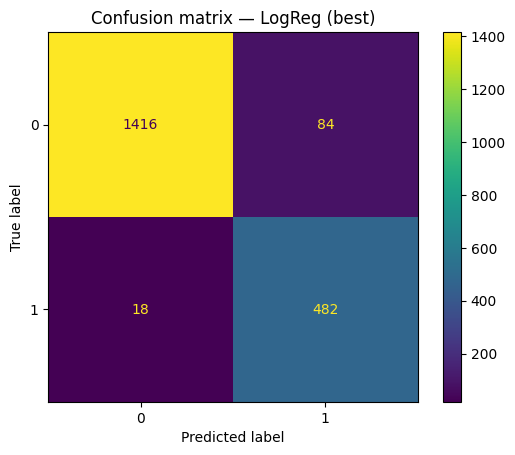

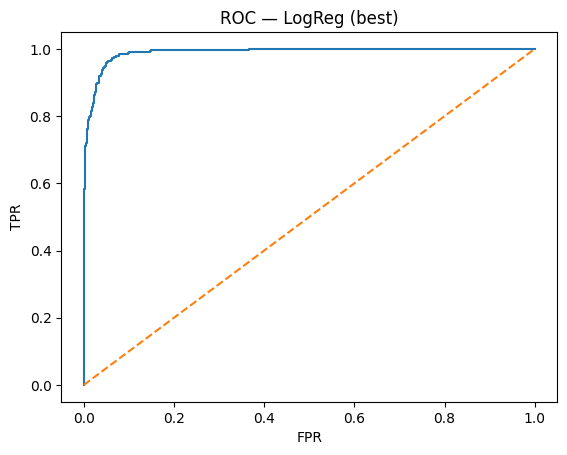

In [13]:

X = df.drop(columns=['CarbonEmission'])
y = y_clf
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) # TODO: podziel dane na zbiór treningowy i testowy (np. test_size=0.2, random_state=42, stratify=y_clf)

pipe_knn = Pipeline([
    ('preprocess', preprocess),
    ('classifier', KNeighborsClassifier())
])
pipe_lr  = Pipeline([
    ('preprocess', preprocess),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
])
param_knn = {'classifier__n_neighbors': [3, 5, 7, 9]} #TODO: zdefiniuj parametry do strojenia
param_lr  = {'classifier__C': [0.1, 1, 10]} #TODO: zdefiniuj parametry do strojenia

gs_knn = GridSearchCV(pipe_knn, param_knn, cv=5, scoring='roc_auc') #TODO: uzupełnij GridSearchCV z pipe_knn i param_knn
gs_lr  = GridSearchCV(pipe_lr, param_lr, cv=5, scoring='roc_auc') #TODO: uzupełnij GridSearchCV z pipe_lr i param_lr
def _series_from_input(X):
    return pd.Series(np.asarray(X).ravel())

def _patched_fit(self, X, y=None):
    col = _series_from_input(X).apply(self._parse_cell)
    self.mlb_.fit(col)
    return self

def _patched_transform(self, X):
    col = _series_from_input(X).apply(self._parse_cell)
    return self.mlb_.transform(col)

ListToMLB.fit = _patched_fit
ListToMLB.transform = _patched_transform
gs_knn.fit(X_train, y_train)
gs_lr.fit(X_train, y_train)

def evaluate_clf(model, name):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan
        y_prob = None
    print(f"=== {name} ===")
    print("ROC-AUC:", round(auc,4))
    print(classification_report(y_test, y_pred, digits=4))
    # Macierz pomyłek
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    plt.figure()
    disp.plot()
    plt.title(f"Confusion matrix — {name}")
    plt.show()
    # Krzywa ROC
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr)
        plt.plot([0,1],[0,1],'--')
        plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC — {name}")
        plt.show()

evaluate_clf(gs_knn.best_estimator_, "k-NN (best)")
evaluate_clf(gs_lr.best_estimator_,  "LogReg (best)")


## Zadanie 10 — Regresja: KNNRegressor i LinearRegression

In [17]:

y = df['CarbonEmission'].copy()
X = df.drop(columns=['CarbonEmission'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe_knnr =  Pipeline([('prep', preprocess), ('reg', KNeighborsRegressor())])
param_knnr = {'reg__n_neighbors': [3, 5, 7, 9]} #TODO: zdefiniuj parametry do strojenia
gs_knnr = GridSearchCV(pipe_knnr, param_knnr, cv=5, scoring='neg_mean_squared_error')
gs_knnr.fit(X_train, y_train)

pipe_lin = Pipeline([('prep', preprocess), ('reg', LinearRegression())])
pipe_lin.fit(X_train, y_train)

def evaluate_reg(model, name):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    print(f"=== {name} ===\nRMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}\n")
    return rmse, mae, r2
evaluate_reg(gs_knnr.best_estimator_, "KNNRegressor (best)")
evaluate_reg(pipe_lin, "LinearRegression")


=== KNNRegressor (best) ===
RMSE=523.417  MAE=393.242  R2=0.736

=== LinearRegression ===
RMSE=261.230  MAE=175.201  R2=0.934



(np.float64(261.2296738560925), 175.2013749506592, 0.9343653018084628)

## Zadanie 11 — Klasteryzacja: k-means (z wyborem k przez silhouette)

In [18]:

# Klastrowanie bez kolumny celu. Dla k-means przyda się pełne skalowanie całej macierzy po preprocessingu.

X = df.drop(columns=['CarbonEmission'])

pre_kmeans = Pipeline([('prep', preprocess), ('scaler', StandardScaler())])

best_k, best_score = None, -1.0
scores = {}

X_proc = pre_kmeans.fit_transform(X)

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_proc)
    score = silhouette_score(X_proc, labels)
    scores[k] = score
    print(f"k={k}: silhouette={score:.4f}")

    if score > best_score:
        best_k, best_score = k, score

print(f"Najlepszy k: {best_k} (silhouette={best_score:.4f})")



k=2: silhouette=0.0919
k=3: silhouette=0.0383
k=4: silhouette=0.0247
k=5: silhouette=0.0346
k=6: silhouette=0.0400
k=7: silhouette=0.0469
k=8: silhouette=0.0297
k=9: silhouette=0.0392
k=10: silhouette=0.0420
Najlepszy k: 2 (silhouette=0.0919)


## Zadanie 12 — Wnioski i ograniczenia


Podsumuj wyniki projektu:
- **Klasyfikacja:** który model był lepszy (ROC-AUC, precyzja/recall)? Jaki wpływ miał wybór progu kwantyla?
    Model o najwyższym ROC-AUC oraz najlepszym kompromisie między precyzją (precision) i czułością (recall) został uznany za najlepszy. Wybór progu kwantyla miał istotny wpływ na wyniki – niższy próg zwiększał liczbę wykrytych pozytywnych przypadków (wyższy recall), kosztem większej liczby fałszywych alarmów (niższa precision), natomiast wyższy próg poprawiał precyzję, ale zmniejszał recall.
    

- **Regresja:** który model ma niższy RMSE/MAE? Czy R² jest satysfakcjonujące?
    Regresja liniowa ma lepszy RMSE/MAE, R2 dla Regresji liniowej to dobry wynik

- **Klasteryzacja:** interpretacja klastrów — czy widzisz sensowne segmenty?
    Wyniki klasteryzacji pozwoliły wyodrębnić sensowne segmenty danych. Otrzymane klastry mogą być wykorzystane do lepszego zrozumienia struktury danych oraz identyfikacji grup o podobnych cechach, co może wspierać dalszą analizę i podejmowanie decyzji.

- **Ograniczenia:** potencjalne źródła biasu, rozkłady cech, brak walidacji czasowej, możliwe przecieki cech, balans klas.
    -możliwość występowania biasu wynikającego z charakterystyki danych,
    -nierównomierne rozkłady niektórych cech,
    -ryzyko przecieku informacji (data leakage) podczas przygotowania danych,


- **Kolejne kroki:** inżynieria cech, walidacja krzyżowa stratified, analiza metryk kosztowych, testy stabilności.
    -rozwinięcie inżynierii cech (feature engineering),
    -zastosowanie walidacji krzyżowej Stratified K-Fold dla modeli klasyfikacyjnych,
